<a href="https://colab.research.google.com/github/sarveshjoshi29/Crypto_Project/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Subset

## ADF Mean-Reversion Sanity Check

Before training a model and running a mean-reversion strategy, confirm that the
underlying series actually exhibits mean reversion. Fit the
**Augmented Dickey-Fuller (ADF) expansion**

$$\Delta y_t \;=\; \alpha \;+\; \lambda\, y_{t-1} \;+\; \sum_{i=1}^{p} \gamma_i\, \Delta y_{t-i} \;+\; \varepsilon_t$$

by OLS. If \( \hat\lambda < 0 \) with a sufficiently negative t-statistic
(critical value \(\approx -2.86\) at 5%), we reject the unit-root null and
conclude the series is mean-reverting with **half-life** \(\ln 2 / (-\lambda)\).

We test three series:
1. `log_return` — expected to be strongly mean-reverting (returns are stationary).
2. `price - rolling_mean(60)` — the *strategy-relevant* residual series.
3. `log(price)` — sanity check; should **not** reject (random walk).


In [2]:
import pandas as pd
import numpy as np

def adf_regression(series, max_lag=5):
    """
    OLS estimator for the ADF expansion
        delta y_t = alpha + lambda * y_{t-1} + sum_i gamma_i * delta y_{t-i} + eps_t
    Returns (lambda_hat, t_stat_lambda, half_life_in_bars).
    A negative lambda with |t| > 2.86 rejects unit root => mean-reverting.
    """
    y = np.asarray(series, dtype=float)
    y = y[~np.isnan(y)]
    dy = np.diff(y)
    y_lag = y[:-1]

    rows = len(dy) - max_lag
    X = np.zeros((rows, 2 + max_lag))
    X[:, 0] = 1.0
    X[:, 1] = y_lag[max_lag:]
    for k in range(1, max_lag + 1):
        X[:, 1 + k] = dy[max_lag - k : len(dy) - k]
    target = dy[max_lag:]

    beta, *_ = np.linalg.lstsq(X, target, rcond=None)
    resid = target - X @ beta
    n, k = X.shape
    sigma2 = float(resid @ resid) / (n - k)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    lam = float(beta[1])
    t_lam = lam / se[1]
    half_life = np.log(2) / (-lam) if lam < 0 else np.inf
    return lam, t_lam, half_life


_df_adf = pd.read_csv('DOGE.csv')
print(f"Loaded {len(_df_adf)} rows for ADF test")

# 1) Log returns (expected: strongly mean-reverting)
log_ret = np.log(_df_adf['Close'] / _df_adf['Close'].shift(1)).dropna()
lam1, t1, hl1 = adf_regression(log_ret.values, max_lag=5)
print("\nADF on log_return:")
print(f"  lambda = {lam1:.6f}   t(lambda) = {t1:.2f}   half-life = {hl1:.2f} bars")

# 2) Residual from rolling mean (strategy-relevant)
window = 60
roll_mean = _df_adf['Close'].rolling(window).mean()
resid = (_df_adf['Close'] - roll_mean).dropna()
lam2, t2, hl2 = adf_regression(resid.values, max_lag=5)
print(f"\nADF on (price - rolling_mean[{window}]):")
print(f"  lambda = {lam2:.6f}   t(lambda) = {t2:.2f}   half-life = {hl2:.2f} bars")

# 3) Log price (sanity check; should NOT reject unit root)
log_p = np.log(_df_adf['Close']).dropna()
lam3, t3, _ = adf_regression(log_p.values, max_lag=5)
print(f"\nADF on log(price) (sanity, should be ~0 and not reject):")
print(f"  lambda = {lam3:.6f}   t(lambda) = {t3:.2f}")

print("\nCritical t-values for ADF (no trend): -3.43 (1%), -2.86 (5%), -2.57 (10%)")
mr_supported = (lam1 < 0 and t1 < -2.86) and (lam2 < 0 and t2 < -2.86)
print(f"\nMean-reversion hypothesis on log_return AND residual series: "
      f"{'SUPPORTED' if mr_supported else 'NOT supported'}")


Loaded 99980 rows for ADF test

ADF on log_return:
  lambda = -1.152128   t(lambda) = -136.10   half-life = 0.60 bars

ADF on (price - rolling_mean[60]):
  lambda = -0.031129   t(lambda) = -38.36   half-life = 22.27 bars

ADF on log(price) (sanity, should be ~0 and not reject):
  lambda = -0.000116   t(lambda) = -2.49

Critical t-values for ADF (no trend): -3.43 (1%), -2.86 (5%), -2.57 (10%)

Mean-reversion hypothesis on log_return AND residual series: SUPPORTED


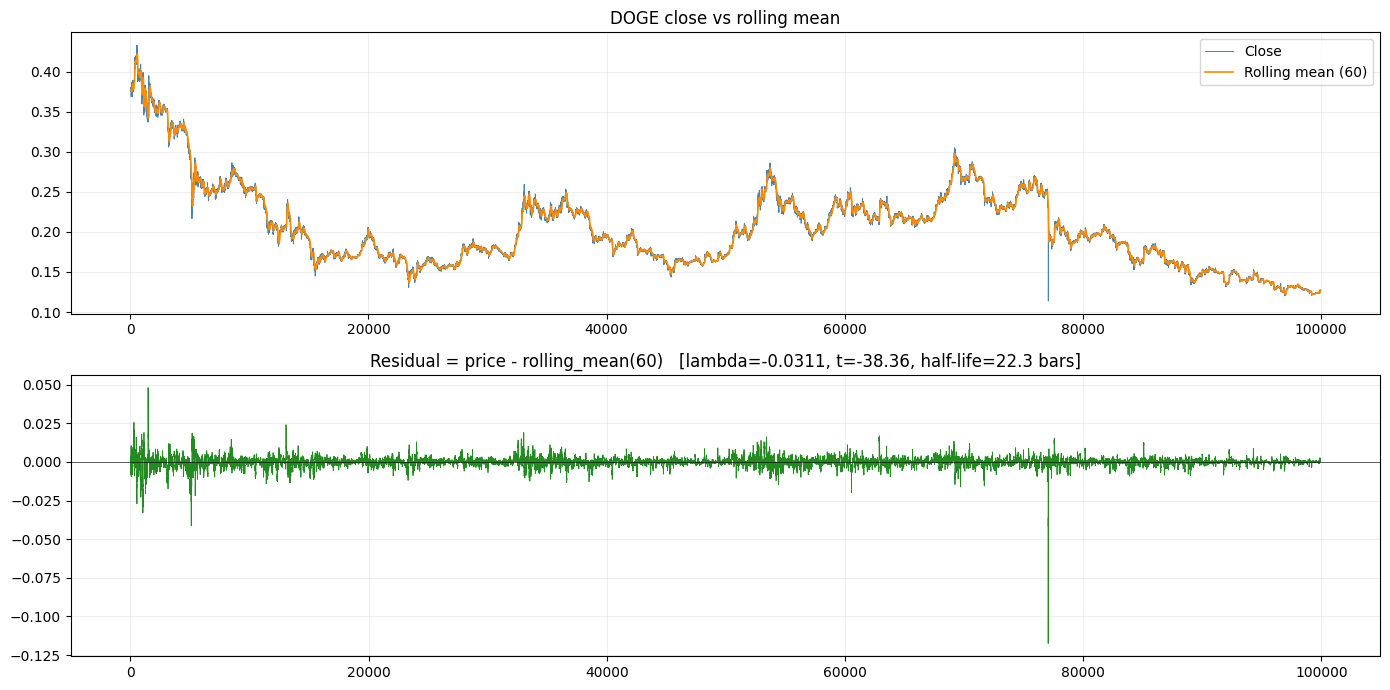

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Top: price and its 60-bar rolling mean
axes[0].plot(_df_adf['Close'].values, color='steelblue', lw=0.7, label='Close')
axes[0].plot(roll_mean.values, color='darkorange', lw=1.2, label=f'Rolling mean ({window})')
axes[0].set_title("DOGE close vs rolling mean")
axes[0].legend(); axes[0].grid(alpha=0.2)

# Bottom: residual (the strategy-relevant series)
axes[1].plot(resid.values, color='forestgreen', lw=0.6)
axes[1].axhline(0, color='black', lw=0.7, alpha=0.6)
axes[1].set_title(f"Residual = price - rolling_mean({window})   "
                  f"[lambda={lam2:.4f}, t={t2:.2f}, half-life={hl2:.1f} bars]")
axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()


In [5]:
class BTCDataset(Dataset):
    def __init__(self, file_path, timesteps=30, train_frac=0.70, val_frac=0.15,
                 scaler_mean=None, scaler_scale=None):
        # 1. Load and Preprocess
        df = pd.read_csv(file_path)

        # 2. Feature Engineering (Stationary Features[Indicators])
        df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
        df['log_range'] = np.log(df['High'] / df['Low'])
        df['rel_body'] = (df['Close'] - df['Open']) / (df['High'] - df['Low'] + 1e-8)
        df['log_vol_change'] = np.log(df['Vol'] / df['Vol'].shift(1) + 1e-8)
        df['rsi_norm'] = df['RSI'] / 100.0
        df['macd_rel'] = df['MACD'] / (df['Close'] + 1e-8)

        df = df.dropna().reset_index(drop=True)

        self.feature_cols = ['log_return', 'log_range', 'rel_body',
                             'log_vol_change', 'rsi_norm', 'macd_rel']

        # 3. Context cols (cyclical time features)
        self.context_cols = ['day_sin', 'day_cos', 'month_sin', 'month_cos',
                             'min_sin', 'min_cos', 'hour_sin', 'hour_cos']

        self.closing_prices = df['Close']

        # 4. Chronological split boundaries
        N_rows = len(df)
        self.train_end_row = int(N_rows * train_frac)
        self.val_end_row   = int(N_rows * (train_frac + val_frac))

        # 5. Scaler -- two modes:
        #    (a) checkpoint stats supplied -> use them verbatim (matches
        #        backtest_local.py, lets a fresh kernel run inference exactly
        #        as the model was trained).
        #    (b) no stats -> fit on the train slice only (no leakage; same as
        #        the original training path).
        self.scaler = StandardScaler()
        if scaler_mean is not None and scaler_scale is not None:
            self.scaler.mean_  = np.asarray(scaler_mean,  dtype=float)
            self.scaler.scale_ = np.asarray(scaler_scale, dtype=float)
            self.scaler.var_   = self.scaler.scale_ ** 2
            self.scaler.n_features_in_ = len(self.feature_cols)
            print(f"[scaler] using checkpoint stats "
                  f"(mean[0]={self.scaler.mean_[0]:.4e}, "
                  f"scale[0]={self.scaler.scale_[0]:.4e})")
        else:
            self.scaler.fit(df.loc[:self.train_end_row - 1, self.feature_cols])
            print("[scaler] fit on train slice")
        df.loc[:, self.feature_cols] = self.scaler.transform(df[self.feature_cols])

        all_needed_cols = self.feature_cols + self.context_cols
        self.data = df[all_needed_cols].astype(np.float32).values
        self.feat_idx   = [all_needed_cols.index(c) for c in self.feature_cols]
        self.ctx_idx    = [all_needed_cols.index(c) for c in self.context_cols]
        self.target_idx = all_needed_cols.index('log_return')
        self.timesteps  = timesteps

    def __len__(self):
        return len(self.data) - self.timesteps

    def __getitem__(self, idx):
        x_seq = self.data[idx : idx + self.timesteps, self.feat_idx]
        x_ctx = self.data[idx + self.timesteps, self.ctx_idx]
        y     = self.data[idx + self.timesteps, self.target_idx]
        return (torch.tensor(x_seq, dtype=torch.float32),
                torch.tensor(x_ctx, dtype=torch.float32),
                torch.tensor(y,     dtype=torch.float32))


full_dataset = BTCDataset('DOGE.csv', timesteps=30,
                          train_frac=0.70, val_frac=0.15)

# Chronological 70/15/15 split.
# A sample at index i uses data[i:i+T] and predicts at i+T.
# To guarantee no leakage across slice boundaries we end each slice T bars early.
T = full_dataset.timesteps
N = len(full_dataset)
train_end = full_dataset.train_end_row - T
val_end   = full_dataset.val_end_row   - T
train_indices = list(range(0, train_end))
val_indices   = list(range(train_end, val_end))
test_indices  = list(range(val_end, N))

train_dataset = Subset(full_dataset, train_indices)
val_dataset   = Subset(full_dataset, val_indices)
test_dataset  = Subset(full_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val   samples: {len(val_dataset)}")
print(f"Test  samples: {len(test_dataset)}")


[scaler] fit on train slice
Train samples: 69955
Val   samples: 14997
Test  samples: 14997


### Model Structure

feature_cols -> 1D Conv -> 2 Stacked LSTMs (with dropout in between) -> Multihead Self Attention -> Concatenate attention output with context data -> MLP Layer -> 2 Heads (mu , sigma) -> Custom Loss function



In [6]:
class Model(nn.Module):
    def __init__(self,timesteps,num_features,context_dim = 8):
        super().__init__()
        self.timesteps = timesteps
        self.num_features = num_features

        self.conv_layer_params = {"out_channels" : 32, "kernel_size" : 3}
        self.LSTM_params = {"LSTM1": 80, "LSTM2" : 64}

        self.conv1d = nn.Conv1d(in_channels=num_features,
                             out_channels=self.conv_layer_params['out_channels'],
                             kernel_size=self.conv_layer_params['kernel_size'],
                             padding='same')

        self.relu = nn.ReLU()
        self.LSTM1 = nn.LSTM(input_size = self.conv_layer_params['out_channels'],batch_first = True,hidden_size = self.LSTM_params["LSTM1"])
        self.dropout1 = nn.Dropout(0.2)
        self.LSTM2 = nn.LSTM(input_size = self.LSTM_params['LSTM1'], batch_first = True,hidden_size = self.LSTM_params["LSTM2"])

        self.num_heads = 4
        self.attention = nn.MultiheadAttention(embed_dim=self.LSTM_params["LSTM2"],
                                               num_heads=self.num_heads,
                                               batch_first=True)
        self.final_dim = self.LSTM_params["LSTM2"] + context_dim
        self.mlp = nn.Sequential(
            nn.Linear(self.final_dim, 32),
            nn.Mish(), # Mish is better for VAEs
            nn.Dropout(0.1)
        )
        self.mu_head = nn.Linear(32, 1)
        self.sigma_head = nn.Linear(32, 1)

    def forward(self,x,context_data):
        x = x.permute(0, 2, 1)
        x = self.conv1d(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)
        x,_ = self.LSTM1(x)
        x = self.dropout1(x)
        x,_ = self.LSTM2(x)
        attn_output, attn_weights = self.attention(x, x, x)
        last_timestep = attn_output[:, -1, :]

        combined = torch.cat((last_timestep, context_data), dim=1)
        hidden = self.mlp(combined)
        mu = self.mu_head(hidden)

        # IMPORTANT: Sigma must ALWAYS be positive. So We use softplus to ensure it stays > 0.
        sigma = F.softplus(self.sigma_head(hidden)) + 1e-6
        return mu, sigma , attn_weights




In [7]:
def custom_loss(mu, sigma, target,lambd = 0.5):
    variance = sigma**2
    return torch.mean(0.5 * torch.log(variance) + 0.5 * (target - mu )**2 / variance + lambd* (target - mu)**2 )

In [8]:
import os
import numpy as _np_for_ckpt
import torch.serialization as _torch_ser
try:
    _torch_ser.add_safe_globals([
        _np_for_ckpt._core.multiarray._reconstruct,
        _np_for_ckpt.ndarray,
        _np_for_ckpt.dtype,
    ])
except Exception:
    pass

CHECKPOINT_PATH = "/content/drive/MyDrive/doge_attention_vol_best.pt"


def load_checkpoint(model, checkpoint_path=CHECKPOINT_PATH, dataset=None,
                    strict=True):
    """
    Mirrors backtest_local.py loading flow:
      1. torch.load(... weights_only=False)
      2. push model weights into `model`
      3. if `dataset` is provided, also push the saved scaler stats into
         `dataset.scaler` so downstream inverse-transforms use the exact stats
         the model was trained on.
    Returns the full checkpoint dict for callers that want metadata.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"No checkpoint at {checkpoint_path}. Train first, or pass a "
            f"different path."
        )
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'], strict=strict)
    model.to(device)

    if dataset is not None and 'scaler_mean' in ckpt and 'scaler_scale' in ckpt:
        dataset.scaler.mean_  = _np_for_ckpt.asarray(ckpt['scaler_mean'],  dtype=float)
        dataset.scaler.scale_ = _np_for_ckpt.asarray(ckpt['scaler_scale'], dtype=float)
        dataset.scaler.var_   = dataset.scaler.scale_ ** 2
        dataset.scaler.n_features_in_ = len(dataset.feature_cols)
        print(f"  [scaler] restored from checkpoint "
              f"(mean[0]={dataset.scaler.mean_[0]:.4e}, "
              f"scale[0]={dataset.scaler.scale_[0]:.4e})")

    print(f"Loaded checkpoint from {checkpoint_path}  "
          f"(epoch {ckpt.get('epoch')}, val NLL {ckpt.get('val_nll'):.6f})")
    return ckpt


In [10]:
def train(model, train_loader, val_loader, epochs=40, lr=1e-3, patience=5,
          checkpoint_path=CHECKPOINT_PATH, dataset_for_scaler=None):
    """
    Train with early stopping on validation NLL. On every new-best epoch the
    checkpoint dict (model state, optimizer state, val NLL, model hparams, AND
    the dataset's scaler stats) is written to `checkpoint_path` on Drive so a
    fresh kernel can later reproduce the exact preprocessing.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    best_val = float('inf')
    bad_epochs = 0
    best_state = None

    os.makedirs(os.path.dirname(checkpoint_path) or ".", exist_ok=True)
    print(f"Starting training on {device}...")
    print(f"Best-checkpoint path: {checkpoint_path}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x_seq, x_ctx, y in train_loader:
            x_seq, x_ctx, y = x_seq.to(device), x_ctx.to(device), y.to(device)
            y = y.view(-1, 1)
            optimizer.zero_grad()
            mu, sigma, _ = model(x_seq, x_ctx)
            loss = custom_loss(mu, sigma, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_seq, x_ctx, y in val_loader:
                x_seq, x_ctx, y = x_seq.to(device), x_ctx.to(device), y.to(device)
                y = y.view(-1, 1)
                mu, sigma, _ = model(x_seq, x_ctx)
                variance = sigma ** 2
                nll = torch.mean(0.5 * torch.log(variance)
                                 + 0.5 * (y - mu) ** 2 / variance)
                val_loss += nll.item()
        avg_val = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train:.6f} | Val NLL: {avg_val:.6f}")

        if avg_val < best_val - 1e-6:
            best_val = avg_val
            bad_epochs = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

            scaler_src = dataset_for_scaler if dataset_for_scaler is not None else (
                full_dataset if 'full_dataset' in globals() else None
            )
            ckpt = {
                'epoch': epoch + 1,
                'model_state': best_state,
                'optimizer_state': optimizer.state_dict(),
                'val_nll': avg_val,
                'model_hparams': {
                    'timesteps':    getattr(model, 'timesteps', 30),
                    'num_features': getattr(model, 'num_features', 6),
                    'context_dim':  8,
                },
            }
            if scaler_src is not None:
                ckpt['scaler_mean']  = scaler_src.scaler.mean_
                ckpt['scaler_scale'] = scaler_src.scaler.scale_
                ckpt['feature_cols'] = scaler_src.feature_cols
                ckpt['context_cols'] = scaler_src.context_cols
            torch.save(ckpt, checkpoint_path)
            print(f"  -> new best, saved to {checkpoint_path}")
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(best Val NLL = {best_val:.6f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best-validation weights (Val NLL = {best_val:.6f}).")
    return model


In [14]:
model = Model(timesteps = 30, num_features = 6)

In [ ]:

train(model, train_loader, val_loader, epochs=40, patience=5,
      dataset_for_scaler=full_dataset)


Starting training on cpu...
Best-checkpoint path: doge_attention_vol_best.pt


KeyboardInterrupt: 

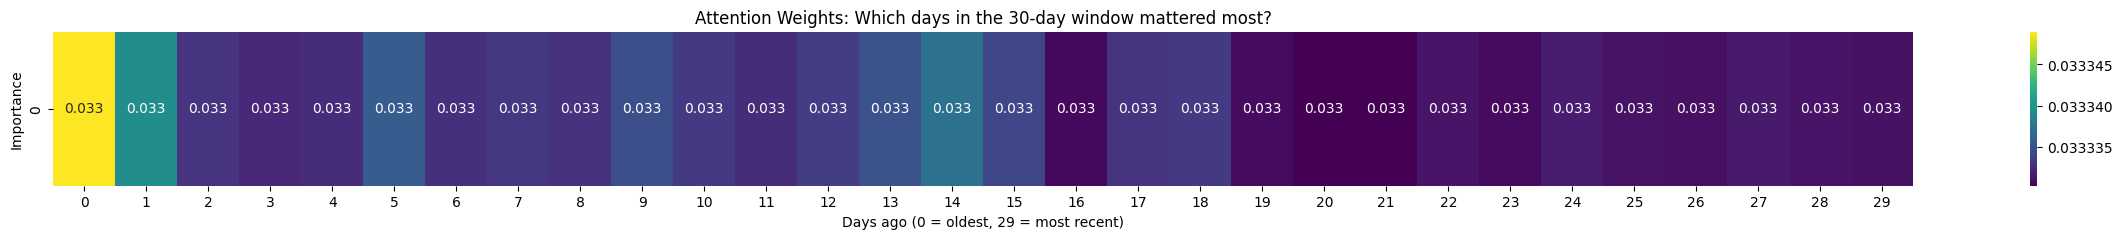

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
CHECKPOINT_PATH = "doge_attention_vol_best.pt"
def plot_attention_weights(attn_weights, window_idx=0):
    """
    Plots the attention weights for a given sample in the batch.
    """
    # We take the weights for the LAST timestep (what the model used for its final summary)
    weights = attn_weights[window_idx, -1, :].cpu().detach().numpy()

    plt.figure(figsize=(30, 2))
    sns.heatmap(weights.reshape(1, -1), annot=True, cmap='viridis', cbar=True)
    plt.title("Attention Weights: Which days in the 30-day window mattered most?")
    plt.xlabel("Days ago (0 = oldest, 29 = most recent)")
    plt.ylabel("Importance")
    plt.show()


model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

myus = []
sigmas = []
with torch.no_grad():
    x_seq, x_ctx, y = next(iter(train_loader))
    mu, sigma, attn_weights = model(x_seq.to(device), x_ctx.to(device))
    myus.append(mu)
    sigmas.append(sigma)
    # Plot the first item in the batch
    plot_attention_weights(attn_weights, window_idx=0)

In [16]:
def predict_and_evaluate(model, test_loader, scaler,
                         checkpoint_path=CHECKPOINT_PATH, load_best=True,
                         dataset=None):
    """
    Runs inference on `test_loader`. By default it first loads the best
    checkpoint from Drive -- model weights AND scaler stats (when a dataset
    is provided) -- so predictions always match how the model was trained.

    Pass `load_best=False` to skip the load (e.g. if you already loaded a
    checkpoint manually) or `dataset=None` to load weights only.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    if load_best:
        load_checkpoint(model, checkpoint_path=checkpoint_path, dataset=dataset)

    model.eval()
    all_mu, all_sigma, all_y = [], [], []
    total_test_loss = 0

    mean_ret = scaler.mean_[0]
    std_ret  = scaler.scale_[0]

    with torch.no_grad():
        for x_seq, x_ctx, y in test_loader:
            x_seq, x_ctx, y = x_seq.to(device), x_ctx.to(device), y.to(device)
            y = y.view(-1, 1)

            mu, sigma, _ = model(x_seq, x_ctx)

            loss = custom_loss(mu, sigma, y)
            total_test_loss += loss.item()

            mu_real    = (mu.cpu().numpy()    * std_ret) + mean_ret
            sigma_real =  sigma.cpu().numpy() * std_ret
            y_real     = (y.cpu().numpy()     * std_ret) + mean_ret

            all_mu.extend(mu_real)
            all_sigma.extend(sigma_real)
            all_y.extend(y_real)

    avg_loss = total_test_loss / len(test_loader)
    print(f"Final Test Loss: {avg_loss:.6f}")

    return np.array(all_mu), np.array(all_sigma), np.array(all_y)


mu_preds, sigma_preds, y_true = predict_and_evaluate(
    model, test_loader, full_dataset.scaler, dataset=full_dataset
)


  [scaler] restored from checkpoint (mean[0]=-4.9490e-06, scale[0]=2.9955e-03)
Loaded checkpoint from doge_attention_vol_best.pt  (epoch 7, val NLL 0.273166)
Final Test Loss: 0.369459


In [17]:
mu_preds.mean()

np.float64(-5.0663927777836707e-05)

In [18]:
sigma_preds.mean()

np.float64(0.002132350308271992)

In [19]:
def check_probabilistic_calibration(mu, sigma, target):
    # Calculate the absolute difference between predicted mean and actual value
    diff = np.abs(target - mu)

    # Check how many points fall within 1 and 2 standard deviations
    within_1std = np.mean(diff <= sigma)
    within_2std = np.mean(diff <= 2 * sigma)

    print("-" * 30)
    print("CALIBRATION RESULTS")
    print("-" * 30)
    print(f"Within 1 Sigma: {within_1std:.2%} (Expected: ~68.2%)")
    print(f"Within 2 Sigma: {within_2std:.2%} (Expected: ~95.4%)")

    # Interpretation
    if within_1std < 0.60:
        print("\nResult: Under-confident. Actual moves are larger than predicted sigma.")
    elif within_1std > 0.80:
        print("\nResult: Over-confident. Sigma is too wide; model is too cautious.")
    else:
        print("\nResult: Well-calibrated! The model understands its own uncertainty.")

check_probabilistic_calibration(mu_preds, sigma_preds, y_true)
indices = test_dataset.indices
prices = np.array(test_dataset.dataset.closing_prices[indices]).flatten()

------------------------------
CALIBRATION RESULTS
------------------------------
Within 1 Sigma: 72.76% (Expected: ~68.2%)
Within 2 Sigma: 94.09% (Expected: ~95.4%)

Result: Well-calibrated! The model understands its own uncertainty.


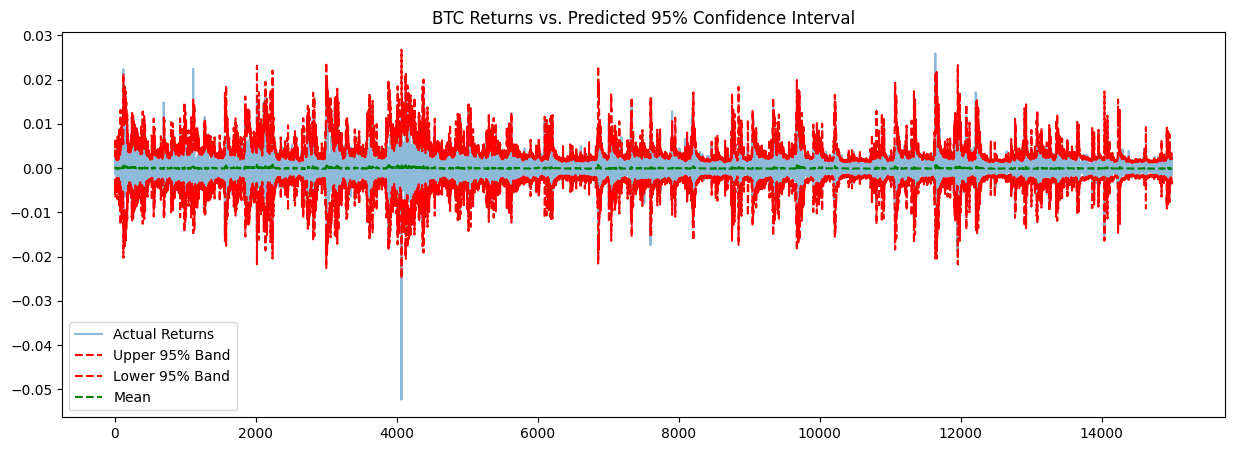

In [20]:
def plot_predicted_band_of_returns(y_true, mu_preds, sigma_preds):

    plt.figure(figsize=(15, 5))
    plt.plot(y_true, label='Actual Returns', alpha=0.5)
    plt.plot(mu_preds + 2*sigma_preds, color='r', linestyle='--', label='Upper 95% Band')
    plt.plot(mu_preds - 2*sigma_preds, color='r', linestyle='--', label='Lower 95% Band')
    plt.plot(mu_preds, color = 'g',linestyle = '--', label = 'Mean')
    plt.title("BTC Returns vs. Predicted 95% Confidence Interval")
    plt.legend()
    plt.show()
plot_predicted_band_of_returns(y_true, mu_preds, sigma_preds)

In [21]:
import numpy as np

def calculate_model_output_sharpe(mu, sigma, risk_free_rate=0,
                                  annualized_factor=np.sqrt(12 * 24 * 365)):
    """
    Sharpe of the MODEL'S OWN FORECAST DISTRIBUTION -- NOT the strategy.
    Treats each bar's predicted (mu, sigma) as a one-step-ahead investment and
    asks 'if you took every forecast at face value, sized 1 unit, what would the
    Sharpe of those mu's be?'.  A negative number here just means the model is
    on-average bearish over the test window -- perfectly fine if you trade short.

    For the actual STRATEGY Sharpe, see `evaluate_strategy_performance` below.
    """
    exp_return = np.exp(mu + 0.5 * sigma ** 2) - 1
    exp_risk   = np.sqrt(np.exp(sigma ** 2) - 1) * np.exp(mu + 0.5 * sigma ** 2)

    mean_return = np.mean(exp_return)
    mean_risk   = np.sqrt(np.mean(exp_risk ** 2))
    overall = ((mean_return - risk_free_rate) / mean_risk) * annualized_factor

    return {
        "overall_sharpe":      overall,
        "expected_return_avg": mean_return,
        "step_sharpe":         (exp_return - risk_free_rate) / exp_risk,
    }


_diag = calculate_model_output_sharpe(mu_preds, sigma_preds)
print("[diagnostic only -- NOT the strategy Sharpe]")
print(f"  Mean predicted bar return: {_diag['expected_return_avg']*1e4:+.2f} bps")
print(f"  'Sharpe of mu/sigma'      : {_diag['overall_sharpe']:+.4f}")
print("  -> negative just means the model is bearish over this test window;")
print("     a short-biased strategy on those forecasts can still profit.")


[diagnostic only -- NOT the strategy Sharpe]
  Mean predicted bar return: -0.47 bps
  'Sharpe of mu/sigma'      : -5.9315
  -> negative just means the model is bearish over this test window;
     a short-biased strategy on those forecasts can still profit.


Max Conviction: 0.0790
Min Conviction: -0.1959
Average Abs Conviction: 0.0567


C:\Users\Sarvesh\AppData\Local\Temp\ipykernel_32156\4190522094.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


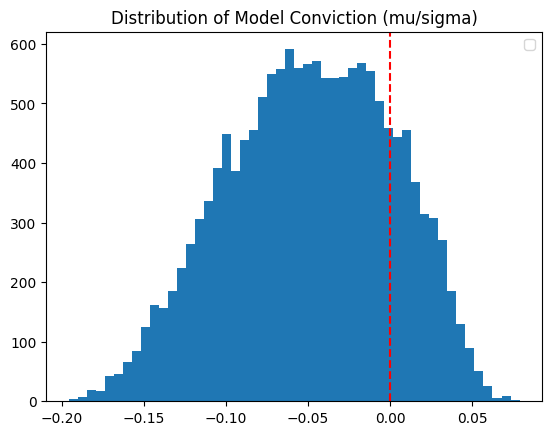

In [22]:
def plot_conviction_distribution(mu_preds, sigma_preds):
    '''Plots the distribution of model conviction (mu/sigma).'''

    # Convert parameters of LogNormal distribution
    temp1 = np.exp(mu_preds + 0.5 * sigma_preds**2) - 1
    temp2 = np.sqrt((np.exp(sigma_preds**2) - 1) * np.exp(2*mu_preds + sigma_preds**2))
    conviction = temp1/temp2
    print(f"Max Conviction: {conviction.max():.4f}")
    print(f"Min Conviction: {conviction.min():.4f}")
    print(f"Average Abs Conviction: {np.abs(conviction).mean():.4f}")

    plt.hist(conviction, bins=50)
    plt.title("Distribution of Model Conviction (mu/sigma)")
    plt.axvline(0.0, color='r', linestyle='--')
    plt.legend()
    plt.show()
plot_conviction_distribution(mu_preds, sigma_preds)

Transaction cost model: 4.0 bps round-trip (2.0 bps per fill)
Number of fills: 246
Total cost paid: $1787.66
Final wealth   : $5686.06   (start = $5000.00)
Strategy return: 13.72%   Buy & Hold: -21.71%


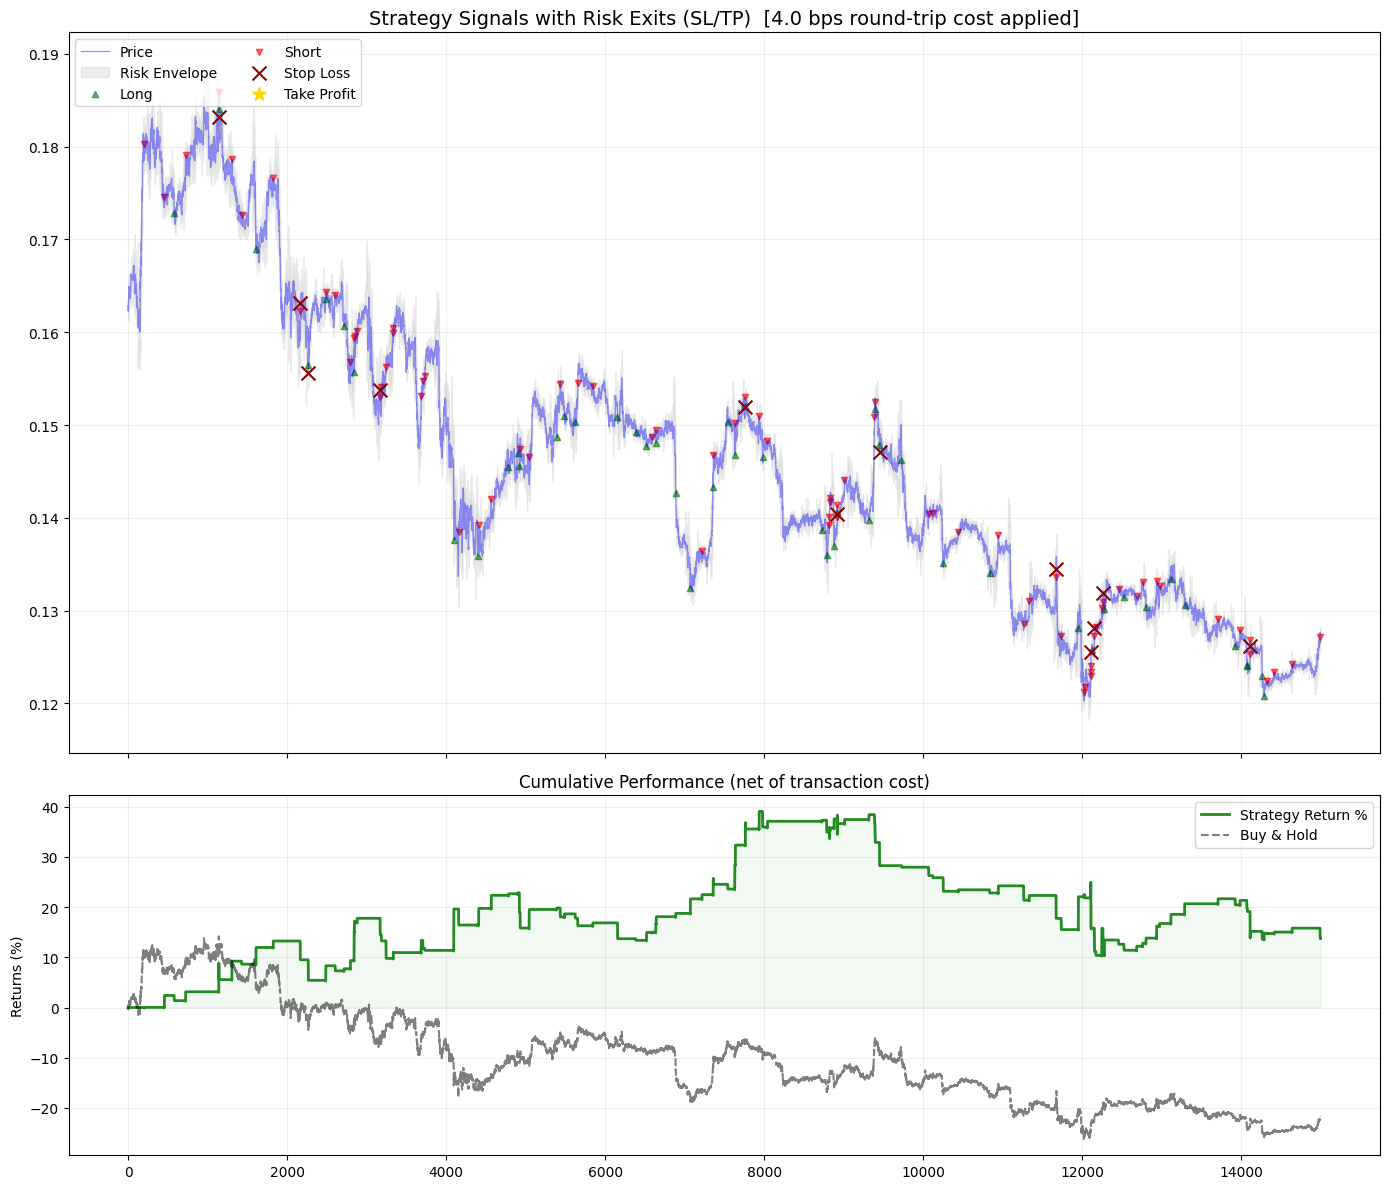

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_volatility_band_backtest(mu, sigma, prices, initial_wealth=5000,
                                 n_sigma=1.75, risk_target=0.03, leverage_cap=6.0,
                                 stop_loss_pct=0.03, take_profit_pct=0.08,
                                 cost_bps_round_trip=10.0):
    """
    Mean Reversion strategy with volatility-band entries, risk-weighted sizing,
    SL/TP exits and a 10 bps round-trip transaction cost (5 bps per fill).


    """
    # Interconversion between normal distribution of price ratio to log-normal distribution of log returns 
    mu_arith    = (np.exp(mu + 0.5 * sigma ** 2) - 1).flatten()
    sigma_arith = (np.sqrt(np.exp(sigma ** 2) - 1)
                   * np.exp(mu + 0.5 * sigma ** 2)).flatten()

    df = pd.DataFrame({
        'price': prices.flatten(),
        'sigma': sigma_arith,
        'mu'   : mu_arith,
    })

    df['upper_band'] = df['price'] * (1 + n_sigma * df['sigma'])
    df['lower_band'] = df['price'] * (1 - n_sigma * df['sigma'])

    df['units_held']  = 0.0
    df['total_wealth'] = float(initial_wealth)
    df['exit_type']   = ""

    current_cash  = initial_wealth
    current_units = 0.0
    entry_price   = 0.0

    # round-trip cost split equally over entry + exit fills
    cost_per_fill = (cost_bps_round_trip / 1e4) / 2.0
    total_cost_paid = 0.0
    n_trades = 0

    for i in range(1, len(df)):
        curr_p = df.loc[i, 'price']
        upper  = df.loc[i - 1, 'upper_band']
        lower  = df.loc[i - 1, 'lower_band']
        current_wealth = current_cash + (current_units * curr_p)

        pnl = 0.0
        if current_units > 0:
            pnl = (curr_p - entry_price) / entry_price
        elif current_units < 0:
            pnl = (entry_price - curr_p) / entry_price

        reason = ""
        if current_units != 0 and pnl <= -stop_loss_pct:
            signal = 0
            reason = "SL"
        elif current_units != 0 and pnl >= take_profit_pct:
            signal = 0
            reason = "TP"
        elif curr_p < lower:
            signal = 1
        elif curr_p > upper:
            signal = -1
        else:
            signal = 0
            if current_units != 0:
                reason = "Mean"

        if signal != 0:
            target_weight =  risk_target / (df.loc[i, 'sigma'] + 1e-9)
            #print("target wight is " , target_weight)
            capped_weight = np.clip(target_weight, 0, leverage_cap)
            target_units  = (current_wealth * capped_weight * signal) / curr_p
            if current_units == 0:
                entry_price = curr_p
        else:
            target_units = 0.0
            entry_price  = 0.0

        units_to_trade = target_units - current_units
        notional       = abs(units_to_trade) * curr_p
        fill_cost      = notional * cost_per_fill
        if notional > 0:
            n_trades += 1
            total_cost_paid += fill_cost

        current_cash  -= units_to_trade * curr_p + fill_cost
        current_units  = target_units

        df.loc[i, 'units_held']   = current_units
        df.loc[i, 'total_wealth'] = current_cash + (current_units * curr_p)
        df.loc[i, 'exit_type']    = reason

    df['strat_cum_ret'] = (df['total_wealth'] / initial_wealth) - 1
    df['bh_cum_ret']    = (df['price'] / df['price'].iloc[0]) - 1

    final_wealth = df['total_wealth'].iloc[-1]
    print(f"Transaction cost model: {cost_bps_round_trip:.1f} bps round-trip "
          f"({cost_per_fill * 1e4:.1f} bps per fill)")
    print(f"Number of fills: {n_trades}")
    print(f"Total cost paid: ${total_cost_paid:.2f}")
    print(f"Final wealth   : ${final_wealth:.2f}   "
          f"(start = ${initial_wealth:.2f})")
    print(f"Strategy return: {(final_wealth / initial_wealth - 1) * 100:.2f}%   "
          f"Buy & Hold: {df['bh_cum_ret'].iloc[-1] * 100:.2f}%")

    plot_performance(df, initial_wealth, cost_bps_round_trip)
    return df


def plot_performance(df, initial_wealth, cost_bps_round_trip=10.0):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(df.index, df['price'], label='Price', color='blue', alpha=0.4, lw=1)
    ax1.fill_between(df.index, df['lower_band'].shift(1), df['upper_band'].shift(1),
                     color='gray', alpha=0.15, label='Risk Envelope')

    longs    = df[df['units_held'] > 0]
    shorts   = df[df['units_held'] < 0]
    sl_exits = df[df['exit_type'] == "SL"]
    tp_exits = df[df['exit_type'] == "TP"]

    ax1.scatter(longs.index,  longs['price'],  marker='^', color='green',
                s=20, label='Long',  alpha=0.6)
    ax1.scatter(shorts.index, shorts['price'], marker='v', color='red',
                s=20, label='Short', alpha=0.6)
    ax1.scatter(sl_exits.index, sl_exits['price'], marker='x',
                color='darkred', s=100, label='Stop Loss',  zorder=5)
    ax1.scatter(tp_exits.index, tp_exits['price'], marker='*',
                color='gold',    s=100, label='Take Profit', zorder=5)

    ax1.set_title(f"Strategy Signals with Risk Exits (SL/TP)  "
                  f"[{cost_bps_round_trip:.1f} bps round-trip cost applied]", fontsize=14)
    ax1.legend(loc='upper left', ncol=2)
    ax1.grid(True, alpha=0.2)

    ax2.plot(df.index, df['strat_cum_ret'] * 100,
             color='forestgreen', label='Strategy Return %', lw=2)
    ax2.plot(df.index, df['bh_cum_ret'] * 100,
             color='black', linestyle='--', alpha=0.5, label='Buy & Hold')
    ax2.fill_between(df.index, 0, df['strat_cum_ret'] * 100,
                     color='green', alpha=0.05)
    ax2.set_title("Cumulative Performance (net of transaction cost)", fontsize=12)
    ax2.set_ylabel("Returns (%)")
    ax2.legend()
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


results = run_volatility_band_backtest(mu_preds, sigma_preds, prices,
                                       n_sigma=4,
                                       stop_loss_pct=0.005,
                                       take_profit_pct=0.03,
                                       cost_bps_round_trip=4.0)


## Evaluation Metrics: Strategy Sharpe, CAGR, Max Drawdown



In [108]:
def evaluate_strategy_performance(results_df, bars_per_year=12 * 24 * 365,
                                  risk_free_rate=0.0):
    """
    Sharpe / CAGR / Max DD of the actual backtest equity curve.
    `results_df` is the DataFrame returned by run_volatility_band_backtest.
    """
    eq = results_df['total_wealth'].values.astype(float)
    rets = np.diff(eq) / eq[:-1]
    rets = rets[np.isfinite(rets)]

    mean_r, std_r = rets.mean(), rets.std()
    sharpe = (mean_r - risk_free_rate / bars_per_year) / std_r * np.sqrt(bars_per_year) if std_r > 0 else np.nan

    n_years = len(rets) / bars_per_year
    total_ret = eq[-1] / eq[0] - 1
    cagr = (eq[-1] / eq[0]) ** (1 / max(n_years, 1e-9)) - 1

    peak = np.maximum.accumulate(eq)
    dd = (eq - peak) / peak
    max_dd = dd.min()

    pos = results_df['units_held'].values
    flips = np.sum(np.sign(pos[1:]) != np.sign(pos[:-1]))
    pct_in_market = np.mean(pos != 0) * 100

    print("=" * 50)
    print("STRATEGY PERFORMANCE (realised, net of costs)")
    print("=" * 50)
    print(f"Bars                : {len(rets):,}  (~{n_years:.3f} years)")
    print(f"Total return        : {total_ret * 100:+.2f}%")
    print(f"CAGR                : {cagr * 100:+.2f}%")
    print(f"Per-bar mean        : {mean_r * 1e4:+.3f} bps")
    print(f"Per-bar std         : {std_r * 1e4:.3f} bps")
    print(f"Sharpe (annualised) : {sharpe:+.4f}")
    print(f"Max drawdown        : {max_dd * 100:.2f}%")
    print(f"Time in market      : {pct_in_market:.1f}%")
    print(f"Position flips      : {flips}")

    return {
        "sharpe": sharpe, "cagr": cagr, "max_dd": max_dd,
        "total_return": total_ret, "rets": rets,
    }


def evaluate_signal_quality(mu_preds, sigma_preds, y_true,
                            bars_per_year=12 * 24 * 365):
    """
    Sharpe of the pure directional signal: trade sign(mu) each bar, sized 1.
    Strips out band logic, SL/TP, sizing. Pure 'does mu point the right way?'.
    """
    mu = np.asarray(mu_preds).flatten()
    y  = np.asarray(y_true).flatten()
    sig = np.sign(mu)

    pnl = sig * y
    pnl = pnl[np.isfinite(pnl)]

    hit_rate = float((np.sign(mu) == np.sign(y)).mean())
    mean_r, std_r = pnl.mean(), pnl.std()
    sharpe = mean_r / std_r * np.sqrt(bars_per_year) if std_r > 0 else np.nan

    conv = mu / (np.asarray(sigma_preds).flatten() + 1e-12)
    pnl_w = conv * y
    sharpe_w = (pnl_w.mean() / pnl_w.std()) * np.sqrt(bars_per_year) if pnl_w.std() > 0 else np.nan
    return {"hit_rate": hit_rate, "sharpe": sharpe, "sharpe_conv": sharpe_w}


strat_stats   = evaluate_strategy_performance(results)
signal_stats  = evaluate_signal_quality(mu_preds, sigma_preds, y_true)


STRATEGY PERFORMANCE (realised, net of costs)
Bars                : 14,996  (~0.143 years)
Total return        : +19.11%
CAGR                : +240.64%
Per-bar mean        : +0.187 bps
Per-bar std         : 37.307 bps
Sharpe (annualised) : +1.6224
Max drawdown        : -34.79%
Time in market      : 10.7%
Position flips      : 2797
